# t-SNE 3D Feature-Space Visualization — Swin (best single model)
Extracts the 256-dim penultimate-layer embedding for every test image from
Swin (the best-performing single model in this study), reduces it to 3D with
t-SNE, and plots it colored by true class. Shows how well-separated the
disease classes are in the model's learned feature space -- a qualitative
complement to the accuracy/F1/AUC numbers reported elsewhere.

Run cells top to bottom (or Runtime → Run all). No TF_USE_LEGACY_KERAS
needed (Swin alone, same as always).

## Cell 1 — Setup

In [3]:
!pip install tfswin --no-deps -q

import os
import shutil
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import tfswin
from tfswin import SwinTransformerTiny224
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import logging
tf.get_logger().setLevel('ERROR')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

print("All imports successful!")

All imports successful!


## Cell 2 — Drive mount

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 3 — Restore test set

In [5]:
split_zip_path = '/content/drive/MyDrive/split_dataset.zip'
csv_zip_path = '/content/drive/MyDrive/thesis_dataset_csv-20260716T043638Z-1-001.zip'

if not os.path.exists('/content/test'):
    shutil.copy(split_zip_path, '/content/split_dataset.zip')
    with zipfile.ZipFile('/content/split_dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/')

if not os.path.exists('/content/csv_data'):
    with zipfile.ZipFile(csv_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/csv_data')

print("Test folder ready:", os.path.exists('/content/test'))

Test folder ready: True


## Cell 4 — Load test CSV + config + dataset

In [6]:
test_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/test_data.csv')
test_df['filepath'] = test_df['filepath'].str.replace('/content/split_dataset', '/content')

class_names = sorted(test_df['label'].unique())
num_classes = len(class_names)
label_to_index = {name: i for i, name in enumerate(class_names)}
true_labels = test_df['label'].map(label_to_index).values

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
filepaths = test_df['filepath'].values

def load_uint8(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(tf.clip_by_value(img, 0, 255), tf.uint8)

def make_ds(load_fn):
    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds_uint8 = make_ds(load_uint8)
print("Test samples:", len(test_df), "| Classes:", num_classes)

Test samples: 2538 | Classes: 12


## Cell 5 — Load Swin, build a feature-extractor sharing the same weights
Two Model objects are built from the same layers: `swin_model` (full
classifier, used to load the trained weights) and `swin_feature_model`
(stops at the 256-dim embedding, right before the final classification
layer). Since they share the exact same layer instances, loading weights
into one updates both.

In [7]:
swin_inputs = layers.Input(shape=(224, 224, 3), dtype='uint8')
swin_base = SwinTransformerTiny224(include_top=False)
x = swin_base(swin_inputs)
x = layers.GlobalAveragePooling2D()(x)
embedding = layers.Dense(256, activation='relu')(x)   # <- the feature we want
x = layers.Dropout(0.4)(embedding)
swin_outputs = layers.Dense(num_classes, activation='softmax')(x)

swin_model = models.Model(swin_inputs, swin_outputs)
swin_model.load_weights('/content/drive/MyDrive/thesis_swintiny_outputs/best_swintiny_model.keras')

swin_feature_model = models.Model(swin_inputs, embedding)
print("Swin loaded. Feature extractor ready (256-dim embedding).")

177485300/177485300 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Swin loaded. Feature extractor ready (256-dim embedding).


## Cell 6 — Sanity check + extract embeddings for the whole test set

In [8]:
from sklearn.metrics import accuracy_score
sanity_preds = swin_model.predict(test_ds_uint8, verbose=1)
sanity_acc = accuracy_score(true_labels, np.argmax(sanity_preds, axis=1))
print(f"Swin test accuracy (sanity check): {sanity_acc:.4f}")

embeddings = swin_feature_model.predict(test_ds_uint8, verbose=1)
print("Embeddings shape:", embeddings.shape)

80/80 ━━━━━━━━━━━━━━━━━━━━ 46s 336ms/step
Swin test accuracy (sanity check): 0.9842
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 302ms/step
Embeddings shape: (2538, 256)


## Cell 7 — Run t-SNE (reduce 256-dim embeddings to 3D)

In [9]:
tsne = TSNE(n_components=3, perplexity=30, random_state=42, init='pca', learning_rate='auto')
embeddings_3d = tsne.fit_transform(embeddings)
print("t-SNE done. Shape:", embeddings_3d.shape)

output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
os.makedirs(output_folder, exist_ok=True)
np.save(f'{output_folder}/tsne_3d_swin.npy', embeddings_3d)
np.save(f'{output_folder}/tsne_3d_swin_labels.npy', true_labels)
print(f"Saved to: {output_folder}/tsne_3d_swin.npy")

t-SNE done. Shape: (2538, 3)
Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/tsne_3d_swin.npy


## Cell 8 — 3D scatter plot, colored by class

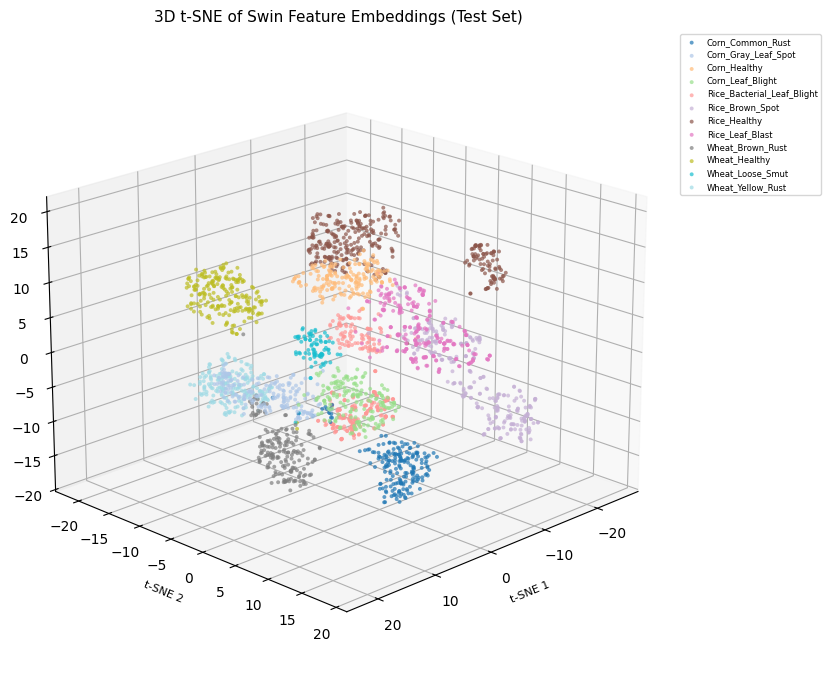

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/tsne_3d_swin.png


In [10]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.tab20(np.linspace(0, 1, num_classes))
for i, cls in enumerate(class_names):
    mask = true_labels == i
    ax.scatter(embeddings_3d[mask, 0], embeddings_3d[mask, 1], embeddings_3d[mask, 2],
               color=colors[i], label=cls, s=8, alpha=0.7, edgecolors='none')

ax.set_xlabel('t-SNE 1', fontsize=8)
ax.set_ylabel('t-SNE 2', fontsize=8)
ax.set_zlabel('t-SNE 3', fontsize=8)
ax.set_title('3D t-SNE of Swin Feature Embeddings (Test Set)', fontsize=11)
ax.legend(fontsize=6, loc='upper left', bbox_to_anchor=(1.02, 1.0), ncol=1)
ax.view_init(elev=20, azim=45)   # adjust viewing angle if classes overlap awkwardly

plt.tight_layout()
plt.savefig(f'{output_folder}/tsne_3d_swin.png', dpi=250, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/tsne_3d_swin.png")

## Cell 9 (optional) — Interactive rotatable version (Plotly)
Saves an HTML file you can open and rotate freely -- useful for exploring
which classes overlap before picking a good static viewing angle for Cell 8.

In [11]:
import plotly.express as px
import pandas as pd

plot_df = pd.DataFrame({
    "x": embeddings_3d[:, 0], "y": embeddings_3d[:, 1], "z": embeddings_3d[:, 2],
    "class": [class_names[i] for i in true_labels],
})

fig = px.scatter_3d(plot_df, x="x", y="y", z="z", color="class",
                     title="3D t-SNE of Swin Feature Embeddings (interactive)",
                     opacity=0.7)
fig.update_traces(marker=dict(size=3))
fig.write_html(f'{output_folder}/tsne_3d_swin_interactive.html')
fig.show()
print(f"Saved to: {output_folder}/tsne_3d_swin_interactive.html")

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/tsne_3d_swin_interactive.html
